In [11]:
import getpass
import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv


load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

In [12]:
from typing import TypedDict

class ParentState(TypedDict):
    user_input:str
    final_answer:str
    
def parent_node(state:ParentState):
    response=llm.invoke(state["user_input"])
    return {"final_answer":response}

In [13]:
class SubgraphState(TypedDict):
    final_answer1:str
    summary_answer:str
    score:str
    

In [14]:
from langchain_core.messages import AnyMessage,SystemMessage,HumanMessage,AIMessage

def subgraph_node_1(state:SubgraphState):
    system_prompt="""
    Please summary the context you receive to 50 words or less
    """
    messages=state["final_answer1"]
    messages=[SystemMessage(content=system_prompt)]+[HumanMessage(content=messages.content)]
    response=llm.invoke(messages)
    return {"summary_answer":response}
    

In [15]:
def subgraph_node_2(state:SubgraphState):
    messages=f"""
    This is the full content of what you received: {state["final_answer1"]} \n
    This information is summarized for the full content:{state["summary_answer"]}
    Please rate the text and summary information, returning a scale of 1 to 10. Note, only return scale value.
    """
    
    response=llm.invoke([HumanMessage(content=messages)])
    
    return {"score":response.content}

In [16]:
from langgraph.graph import StateGraph,START

subgraph_builder=StateGraph(SubgraphState)
subgraph_builder.add_node(subgraph_node_1)
subgraph_builder.add_node(subgraph_node_2)
subgraph_builder.add_edge(START,"subgraph_node_1")
subgraph_builder.add_edge("subgraph_node_1","subgraph_node_2")

subgraph=subgraph_builder.compile()

In [17]:
def parentgraph_node2(state:ParentState):
    
    response=subgraph.invoke({"final_answer1":state["final_answer"]})
    return {"final_answer":response["score"]}

In [18]:
builder=StateGraph(ParentState)
builder.add_node("node_1",parent_node)
builder.add_node("node_2",parentgraph_node2)


builder.add_edge(START,"node_1")
builder.add_edge("node_1","node_2")

graph=builder.compile()

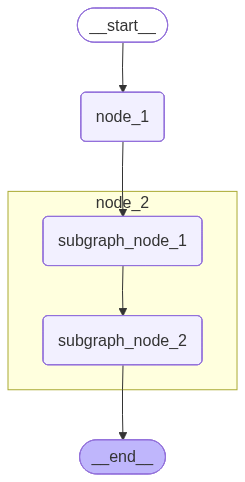

In [19]:
from IPython.display import display,Image

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [20]:
async for chunk in graph.astream({"user_input":"我现在想学习大模型，应该关注哪些技术"},stream_mode="values",subgraphs=True):
    print(chunk)

((), {'user_input': '我现在想学习大模型，应该关注哪些技术'})
((), {'user_input': '我现在想学习大模型，应该关注哪些技术', 'final_answer': AIMessage(content='学习大模型（Large Language Models, LLMs）是一个系统性的工程，涉及从理论到实践的多个层面。为了帮助你高效入门，我将技术栈分为**四个核心阶段**，并标注了当前（2025年）最值得关注的关键技术点。\n\n### 第一阶段：基础理论与数学（地基）\n**目标**：理解大模型“为什么能工作”，而不是只会调包。\n\n-   **Transformer架构**：这是所有大模型的基石。你需要深入理解**自注意力机制（Self-Attention）**、**多头注意力（Multi-Head Attention）**、**位置编码（Positional Encoding，尤其是RoPE旋转位置编码）** 以及**Feed-Forward Network**。\n-   **预训练与微调范式**：理解“预训练（Pre-training） + 微调（Fine-tuning）”的两阶段范式。特别是**指令微调（Instruction Tuning）** 和**RLHF（基于人类反馈的强化学习）** 如何让模型对齐人类偏好。\n-   **关键数学工具**：线性代数（矩阵运算）、概率论（交叉熵损失）、微积分（反向传播）。不需要精通，但需要理解其在大模型中的角色。\n\n### 第二阶段：核心工程与训练（动手能力）\n**目标**：知道如何训练、部署和优化一个模型。\n\n-   **分布式训练框架**：大模型无法单卡训练。必须掌握：\n    -   **数据并行（Data Parallelism）**、**模型并行（Model Parallelism）**、**流水线并行（Pipeline Parallelism）**。\n    -   **ZeRO优化器**（DeepSpeed的核心）：如何通过分片减少显存占用。\n    -   **混合精度训练（FP16/BF16）**：理解精度对训练稳定性的影响。\n-   **高效微调技术（PEFT）**：这是个人或小团队使用大模型的关键。\n    -   **LoRA（低秩